In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid")

## Accuracy

In [12]:
accuracy = pd.DataFrame.from_dict({
    'SVM': 0.9635,
    'SVM 1-2-grams': 0.97069,
    'Multi-Layer Perceptron': 0.96314,
    'Logistic Regression': 0.940497,
    'Gradient Boosting': 0.910301,
    'fine-tuned BERT tiny': 0.96344,
    'fine-tuned BERT base': 0.983438,
}, orient='index').sort_values(by=0).transpose()

accuracy

,Gradient Boosting,Logistic Regression,Multi-Layer Perceptron,fine-tuned BERT tiny,SVM,SVM 1-2-grams,fine-tuned BERT base
0,0.910301,0.940497,0.96314,0.96344,0.9635,0.97069,0.983438


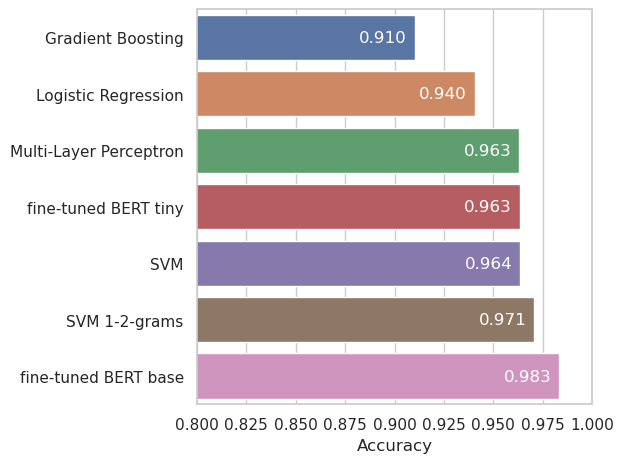

In [37]:
f, ax = plt.subplots()

ax.set_xlim(0.8, 1.0)
ax.set_xlabel('Accuracy')
sns.set_color_codes('pastel')
sns.barplot(data=accuracy, orient='h')

ax.bar_label(ax.containers[-1], fmt='%.3f', padding=-40, color='white')
f.tight_layout()
f.savefig('figures/accuracy_barplot.pdf')

## Wordclouds

In [1]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 1.1 MB/s eta 0:00:000:00:01m eta 0:00:01


In [5]:
from wordcloud import WordCloud

In [9]:
WordCloud.generate_from_frequencies?

Signature: WordCloud.generate_from_frequencies(self, frequencies, max_font_size=None)
Docstring:
Create a word_cloud from words and frequencies.

Parameters
----------
frequencies : dict from string to float
    A contains words and associated frequency.

max_font_size : int
    Use this font-size instead of self.max_font_size

Returns
-------
self
File:      ~/.local/lib/python3.10/site-packages/wordcloud/wordcloud.py
Type:      function

In [30]:
positive_words = pd.read_csv('positive_words.csv').set_index('word')
negative_words = pd.read_csv('negative_words.csv').set_index('word')



In [34]:
args = {
    'background_color': 'white',
}

wc_pos = WordCloud(**args).generate_from_frequencies(positive_words.to_dict()['coefficient'])
wc_neg = WordCloud(**args).generate_from_frequencies(negative_words.to_dict()['coefficient'])

In [35]:
with open('figures/wordcloud_positive.svg', 'w') as f:
    f.write(wc_pos.to_svg())
    
with open('figures/wordcloud_negative.svg', 'w') as f:
    f.write(wc_neg.to_svg())